<a href="https://colab.research.google.com/github/haifad16/2310010216_MuhammadHaifadIlham_UTS/blob/main/2310010216_Muhammad%20Haifad%20Ilham_UAS_JST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_11197/3324640941.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2026-06-01")
[*********************100%***********************]  1 of 1 completed


=== 5 Data Pertama Saham BBCA ===
Price             Harga
Ticker          BBCA.JK
Date                   
2022-01-03  6297.416992
2022-01-04  6361.895020
2022-01-05  6404.881348
2022-01-06  6426.374512
2022-01-07  6576.824219

Total baris data yang berhasil diambil: 1054 baris (Memenuhi syarat UAS).



<Figure size 1200x600 with 0 Axes>

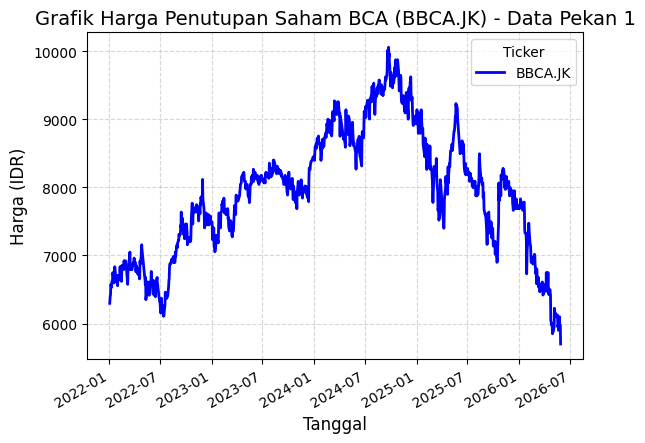

In [1]:
# ==========================================
# PEKAN 1: PENGAMBILAN & EKSPLORASI DATASET
# ==========================================

# 1. Install library yfinance untuk mengambil data saham langsung dari Yahoo Finance
!pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 2. Mengunduh data historis saham BBCA (Bank Central Asia)
# Kita ambil data selama 4 tahun terakhir agar mendapatkan > 900 baris data (Memenuhi syarat minimal 500-1000 baris)
ticker = "BBCA.JK"
df = yf.download(ticker, start="2022-01-01", end="2026-06-01")

# 3. Data Cleaning & Setup Time Series awal
# Kita hanya membutuhkan kolom tanggal dan harga penutupan (Close) sebagai target prediksi
df = df[['Close']].rename(columns={'Close': 'Harga'})

# Memastikan indeks tanggal bertipe datetime (Sesuai instruksi Project UAS.pdf)
df.index = pd.to_datetime(df.index)

# Tampilkan 5 baris data pertama untuk pengecekan
print("=== 5 Data Pertama Saham BBCA ===")
print(df.head())
print(f"\nTotal baris data yang berhasil diambil: {len(df)} baris (Memenuhi syarat UAS).\n")

# 4. Visualisasi Awal (Line Plot)
plt.figure(figsize=(12, 6))
df['Harga'].plot(color='blue', linewidth=2)
plt.title('Grafik Harga Penutupan Saham BCA (BBCA.JK) - Data Pekan 1', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga (IDR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [8]:
# Kode untuk menyimpan data dari Google Colab menjadi file CSV/Excel di laptop Anda
df.to_csv("data_saham_bbca.csv")
print("File 'data_saham_bbca.csv' berhasil dibuat! Silakan cek di folder sebelah kiri Google Colab Anda.")

File 'data_saham_bbca.csv' berhasil dibuat! Silakan cek di folder sebelah kiri Google Colab Anda.


In [5]:
# ===================================================
# PEKAN 2: PREPROCESSING DATA & SLIDING WINDOW (JST)
# ===================================================

import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Normalisasi Data (Mengubah skala ke 0 - 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['Harga']])

# 2. Pembuatan Fungsi Sliding Window
def create_sliding_window(data, window_size):
    X = []
    y = []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0]) # Mengambil data sebanyak window_size hari
        y.append(data[i + window_size, 0])     # Mengambil data hari berikutnya sebagai target
    return np.array(X), np.array(y)

# Kita tentukan window_size = 5 hari bursa
WINDOW_SIZE = 5
X, y = create_sliding_window(scaled_data, WINDOW_SIZE)

# 3. Split Data Berurutan (80% Training, 20% Testing)
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Tampilkan hasil pengecekan struktur data
print("=== Hasil Pemrosesan Data Pekan 2 ===")
print(f"Bentuk Data Input (X) Train: {X_train.shape} -> {X_train.shape[0]} sampel, masing-masing {X_train.shape[1]} hari masa lalu.")
print(f"Bentuk Data Target (y) Train: {y_train.shape} -> {y_train.shape[0]} nilai tebakan.")
print(f"Total data Training: {len(X_train)} baris")
print(f"Total data Testing : {len(X_test)} baris")

print("\nContoh Potongan Kasus Pertama (X_train[0] -> menebak y_train[0]):")
print(f"Input (Harga 5 hari berturut-turut yang dinormalisasi): {X_train[0]}")
print(f"Target (Harga hari ke-6 yang harus ditebak AI)        : {y_train[0]}")

=== Hasil Pemrosesan Data Pekan 2 ===
Bentuk Data Input (X) Train: (839, 5) -> 839 sampel, masing-masing 5 hari masa lalu.
Bentuk Data Target (y) Train: (839,) -> 839 nilai tebakan.
Total data Training: 839 baris
Total data Testing : 210 baris

Contoh Potongan Kasus Pertama (X_train[0] -> menebak y_train[0]):
Input (Harga 5 hari berturut-turut yang dinormalisasi): [0.13700399 0.15179056 0.16164849 0.16657746 0.20107967]
Target (Harga hari ke-6 yang harus ditebak AI)        : 0.1912218505856913


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


=== Sedang Melatih AI (Training), Silakan Tunggu... ===
Training Selesai!



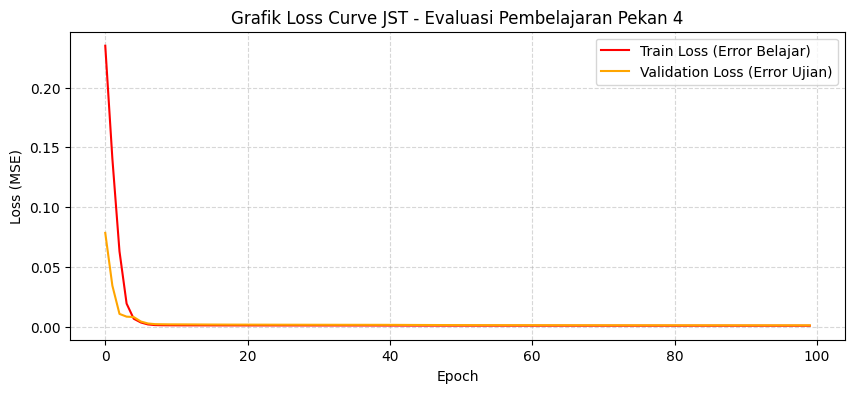

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

=== HASIL AKHIR EVALUASI PROYEK ===
Nilai RMSE Model JST Anda: 142.24 IDR


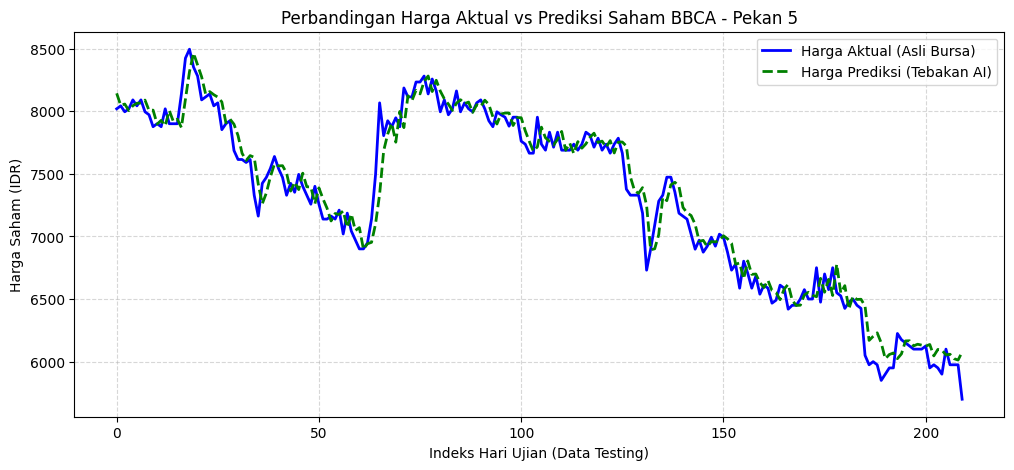

In [7]:
# =====================================================================
# GABUNGAN PEKAN 2 - PEKAN 5: PREPROCESSING, ARSITEKTUR, TRAINING & EVALUASI
# =====================================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math

# --- PEKAN 2: PREPROCESSING & SLIDING WINDOW ---
# 1. Normalisasi Data (Skala 0 - 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['Harga']])

# 2. Membuat Fungsi Sliding Window (window_size = 5)
def create_sliding_window(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

WINDOW_SIZE = 5
X, y = create_sliding_window(scaled_data, WINDOW_SIZE)

# 3. Split Data (80% Training, 20% Testing secara berurutan)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


# --- PEKAN 3: DESAIN ARSITEKTUR JST ---
tf.random.set_seed(42)
model = Sequential([
    Dense(12, activation='relu', input_dim=WINDOW_SIZE), # Input & Hidden Layer 1
    Dense(8, activation='relu'),                        # Hidden Layer 2
    Dense(1)                                             # Output Layer
])
model.compile(optimizer='adam', loss='mean_squared_error')


# --- PEKAN 4: PROSES TRAINING ---
print("=== Sedang Melatih AI (Training), Silakan Tunggu... ===")
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), verbose=0)
print("Training Selesai!\n")

# Tampilkan Grafik Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss (Error Belajar)', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss (Error Ujian)', color='orange')
plt.title('Grafik Loss Curve JST - Evaluasi Pembelajaran Pekan 4', fontsize=12)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss (MSE)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# --- PEKAN 5: EVALUASI PREDIKSI ---
# 1. AI Melakukan Prediksi
y_pred_scaled = model.predict(X_test)

# 2. Denormalisasi (Kembalikan ke angka Rupiah asli)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred_scaled)

# 3. Hitung Nilai RMSE
rmse = math.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
print("\n=== HASIL AKHIR EVALUASI PROYEK ===")
print(f"Nilai RMSE Model JST Anda: {rmse:.2f} IDR")

# 4. Tampilkan Grafik Hasil Perbandingan Akhir
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label='Harga Aktual (Asli Bursa)', color='blue', linewidth=2)
plt.plot(y_pred_actual, label='Harga Prediksi (Tebakan AI)', color='green', linestyle='--', linewidth=2)
plt.title('Perbandingan Harga Aktual vs Prediksi Saham BBCA - Pekan 5', fontsize=12)
plt.xlabel('Indeks Hari Ujian (Data Testing)', fontsize=10)
plt.ylabel('Harga Saham (IDR)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

=== Arsitektur JST Berhasil Dibuat ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185 (740.00 B)

 Trainable params: 185 (740.00 B)

 Non-trainable params: 0 (0.00 B)


=== Memulai Proses Training AI (Silakan Tunggu...) ===
Training Selesai!


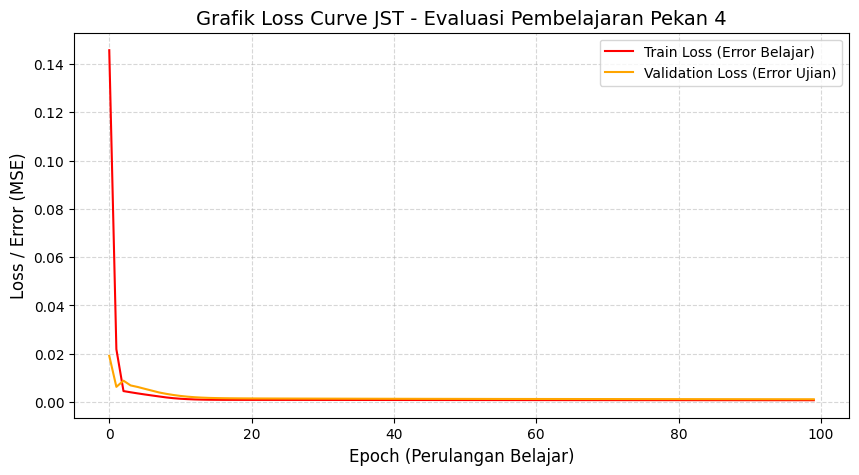

In [3]:
# ===================================================
# PEKAN 3 & 4: ARSITEKTUR JST & PROSES TRAINING (AI)
# ===================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Fix random seed agar hasil perhitungan konsisten saat dijalankan ulang
tf.random.set_seed(42)

# --- PEKAN 3: DESAIN ARSITEKTUR JST ---
model = Sequential([
    # Lapisan Input & Hidden Layer 1: 12 Neuron, menerima input sebanyak WINDOW_SIZE (5)
    Dense(12, activation='relu', input_dim=WINDOW_SIZE),

    # Hidden Layer 2: 8 Neuron dengan fungsi aktivasi ReLU
    Dense(8, activation='relu'),

    # Lapisan Output: 1 Neuron untuk mengeluarkan 1 angka hasil tebakan harga saham
    Dense(1)
])

# Compile Model: Menentukan optimizer (Adam) dan fungsi pengukur error (MSE)
model.compile(optimizer='adam', loss='mean_squared_error')

print("=== Arsitektur JST Berhasil Dibuat ===")
model.summary()


# --- PEKAN 4: PROSES TRAINING MODEL ---
print("\n=== Memulai Proses Training AI (Silakan Tunggu...) ===")
# AI akan belajar sebanyak 100 epoch dengan ukuran batch 32
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0 # Mengurangi text log agar Colab tetap rapi
)
print("Training Selesai!")

# Visualisasi Loss Curve (Kurva Pembelajaran AI)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (Error Belajar)', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss (Error Ujian)', color='orange')
plt.title('Grafik Loss Curve JST - Evaluasi Pembelajaran Pekan 4', fontsize=14)
plt.xlabel('Epoch (Perulangan Belajar)', fontsize=12)
plt.ylabel('Loss / Error (MSE)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()